### Importación de datos



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
987,Bloques de construcción,Juguetes,42400.0,0.0,13/03/2022,Lucas Olivera,Bogotá,3,Nequi,1,4.60971,-74.08175
1847,Ajedrez de madera,Juguetes,20800.0,0.0,30/09/2022,Pedro Gomez,Bogotá,4,Cupón,1,4.60971,-74.08175
2299,Cuerda para saltar,Deportes y diversión,8300.0,0.0,19/01/2020,Felipe Santos,Medellín,5,Tarjeta de crédito,1,6.25184,-75.56359
2296,Cuerda para saltar,Deportes y diversión,13400.0,0.0,27/11/2020,Santiago Silva,Bogotá,5,Tarjeta de crédito,1,4.60971,-74.08175
74,Balón de voleibol,Deportes y diversión,42600.0,0.0,23/10/2022,Felipe Santos,Bogotá,3,Tarjeta de crédito,2,4.60971,-74.08175
...,...,...,...,...,...,...,...,...,...,...,...,...
1806,TV LED UHD 4K,Electrónicos,2851600.0,150000.0,08/09/2021,Izabela de León,Santa Marta,3,Tarjeta de crédito,1,11.24079,-74.19904
375,TV LED UHD 4K,Electrónicos,2861000.0,150500.0,20/09/2022,Santiago Silva,Bogotá,5,Tarjeta de crédito,3,4.60971,-74.08175
603,TV LED UHD 4K,Electrónicos,2762900.0,151800.0,20/06/2020,Juliana Costa,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
104,TV LED UHD 4K,Electrónicos,2899800.0,152600.0,08/07/2021,Maria Alfonso,Bogotá,1,Tarjeta de crédito,6,4.60971,-74.08175


#1. Análisis de facturación



In [ ]:
df_tiendas = pd.DataFrame()
df_tiendas["nombre"] = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
df_tiendas["ingreso total"] = [tienda.Precio.sum(),tienda2.Precio.sum(),tienda3.Precio.sum(),tienda4.Precio.sum()]
df_tiendas = df_tiendas.set_index("nombre")
df_tiendas.style.format({"ingreso total": "${:,.0f}"})

,ingreso total
nombre,
tienda1,"$1,150,880,400"
tienda2,"$1,116,343,500"
tienda3,"$1,098,019,600"
tienda4,"$1,038,375,700"


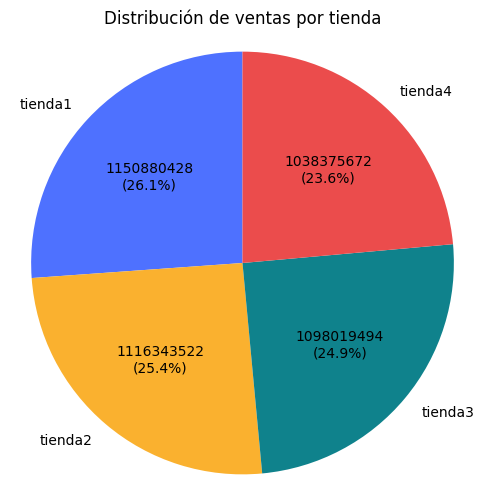

In [ ]:
total = df_tiendas['ingreso total'].sum()
def mostrar_valor_y_porcentaje(pct):
    valor_absoluto = int(round(pct * total / 100))
    return f"{valor_absoluto}\n({pct:.1f}%)"

plt.figure(figsize=(6, 6))

plt.pie(
    df_tiendas['ingreso total'],
    labels=df_tiendas.index,
    colors=["#4E71FF", "#FAB12F", "#0F828C", "#EB4C4C"],
    autopct=mostrar_valor_y_porcentaje,
    startangle=90
)

plt.title('Distribución de ventas por tienda')
plt.axis('equal')
plt.show()


# 2. Ventas por categoría

In [ ]:
print('Tienda N°1')
venta_categorias_tienda = tienda['Categoría del Producto'].value_counts().sort_values(ascending=False)
print(venta_categorias_tienda)
print()
print('Tienda N°2')
venta_categorias_tienda2 = tienda2['Categoría del Producto'].value_counts().sort_values(ascending=False)
print(venta_categorias_tienda2)
print()
print('Tienda N°3')
venta_categorias_tienda3 = tienda3.groupby('Categoría del Producto').size().sort_values(ascending=False)
print(venta_categorias_tienda3)
print()
print('Tienda N°4')
venta_categorias_tienda4 = tienda4.groupby('Categoría del Producto').size().sort_values(ascending=False)
print(venta_categorias_tienda4)


Tienda N°1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Tienda N°2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Tienda N°3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Artículos para el hogar    177
Instrumentos musicales     177
dtype: int64

Tienda N°4
Categoría del Producto
Muebles                    480
Electrónicos         

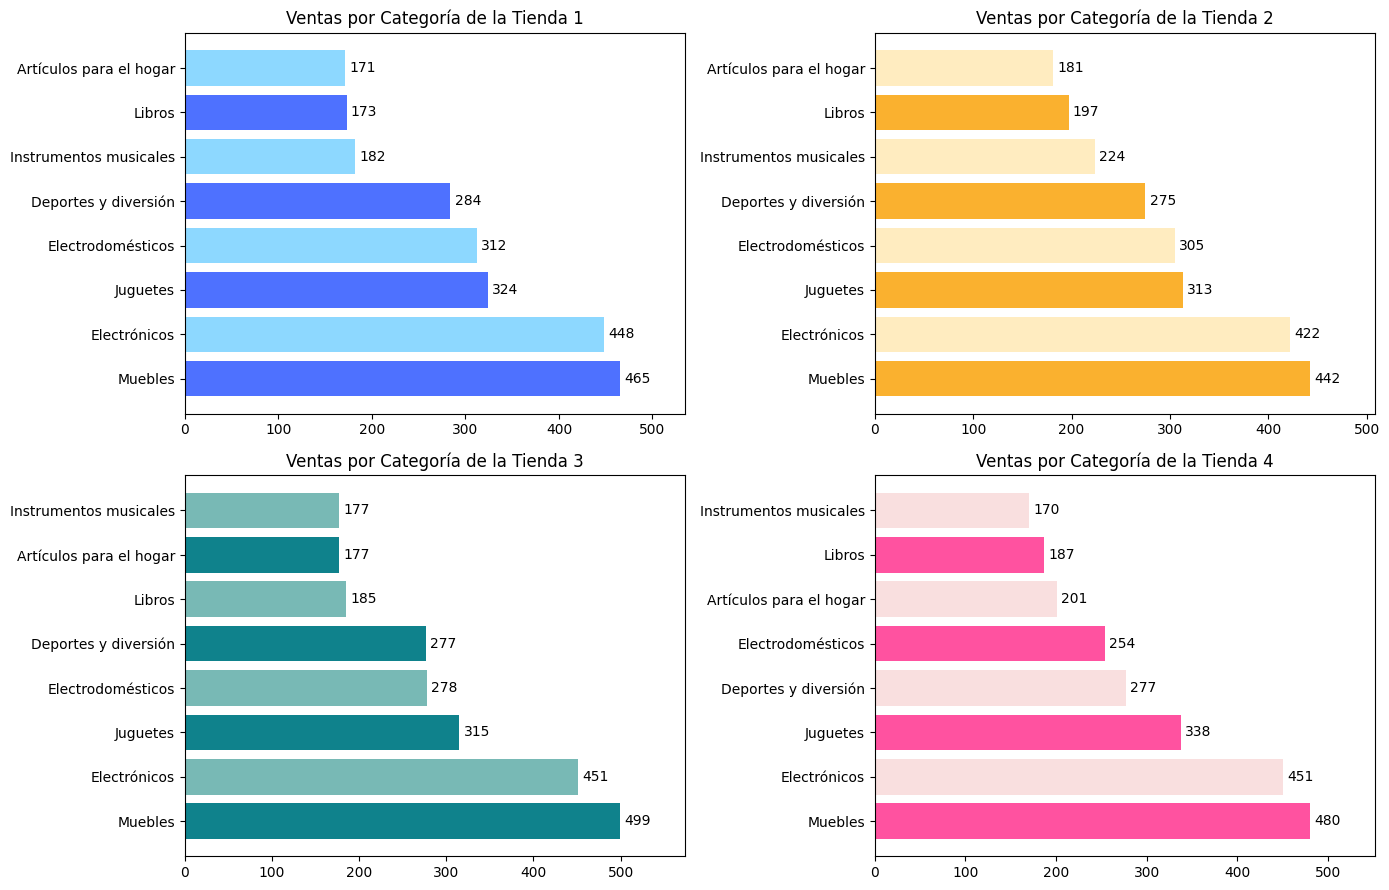

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# Arriba izquierda
barras1 = axs[0, 0].barh(venta_categorias_tienda.index, venta_categorias_tienda.values,color=["#4E71FF", "#8DD8FF"])
axs[0, 0].set_title('Ventas por Categoría de la Tienda 1')
axs[0, 0].bar_label(barras1, padding=3)
axs[0, 0].margins(x=0.15)

# Arriba derecha
barras2 = axs[0, 1].barh(venta_categorias_tienda2.index, venta_categorias_tienda2.values,color=["#FAB12F","#FFECC0"])
axs[0, 1].set_title('Ventas por Categoría de la Tienda 2')
axs[0, 1].bar_label(barras2, padding=3)
axs[0, 1].margins(x=0.15)

# Abajo izquierda
barras3 = axs[1, 0].barh(venta_categorias_tienda3.index, venta_categorias_tienda3.values,color=["#0F828C", "#78B9B5"])
axs[1, 0].set_title('Ventas por Categoría de la Tienda 3')
axs[1, 0].bar_label(barras3, padding=3)
axs[1, 0].margins(x=0.15)

# Abajo derecha
barras4 = axs[1, 1].barh(venta_categorias_tienda4.index, venta_categorias_tienda4.values,color=["#FF52A0", "#F9DFDF"])
axs[1, 1].set_title('Ventas por Categoría de la Tienda 4')
axs[1, 1].bar_label(barras4, padding=3)
axs[1, 1].margins(x=0.15)

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [ ]:
df_tiendas["calificacion promedio"] = [tienda.Calificación.mean(),tienda2.Calificación.mean(),tienda3.Calificación.mean(),tienda4.Calificación.mean()]
df_tiendas[["calificacion promedio"]].style.format(
    {"ingreso total": "${:,.2f}",
    "calificacion promedio": "{:.2f}"})

,calificacion promedio
nombre,
tienda1,3.98
tienda2,4.04
tienda3,4.05
tienda4,4.00


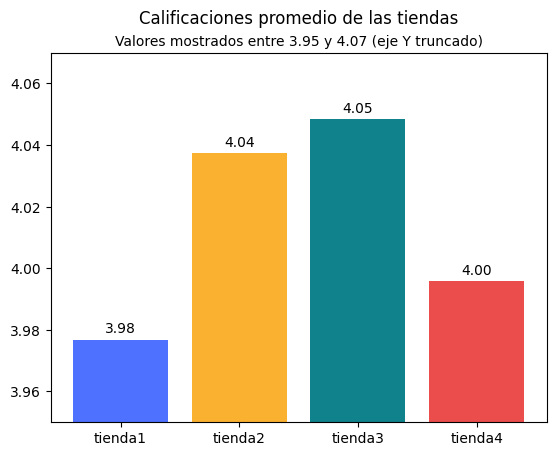

In [ ]:
barras = plt.bar(df_tiendas.index, df_tiendas["calificacion promedio"], color=["#4E71FF", "#FAB12F", "#0F828C", "#EB4C4C"])
plt.gca().set_ylim(3.95, 4.07)
plt.title("Calificaciones promedio de las tiendas\n", fontsize=12)
plt.text(
    0.5, 1.02,
    "Valores mostrados entre 3.95 y 4.07 (eje Y truncado)",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=10
)
plt.bar_label(barras,fmt="%.2f", padding=3)
plt.show()

# 4. Productos más y menos vendidos

In [ ]:
venta_productos_tienda1 = tienda.groupby('Producto').size().sort_values(ascending=False)
top_tienda1 = venta_productos_tienda1.head(3)
bottom_tienda1 = venta_productos_tienda1.tail(3)
top_bottom_tienda1 = pd.concat([top_tienda1,bottom_tienda1])
print("Productos Mas y Menos Vendidos de la Tienda N°1")
print(top_bottom_tienda1)
print()
venta_productos_tienda2 = tienda2.groupby('Producto').size().sort_values(ascending=False)
top_tienda2 = venta_productos_tienda2.head(3)
bottom_tienda2 = venta_productos_tienda2.tail(3)
top_bottom_tienda2 = pd.concat([top_tienda2,bottom_tienda2])
print("Productos Mas y Menos Vendidos de la Tienda N°2")
print(top_bottom_tienda2)
print()
venta_productos_tienda3 = tienda3.groupby('Producto').size().sort_values(ascending=False)
top_tienda3 = venta_productos_tienda3.head(3)
bottom_tienda3 = venta_productos_tienda3.tail(3)
top_bottom_tienda3 = pd.concat([top_tienda3,bottom_tienda3])
print("Productos Mas y Menos Vendidos de la Tienda N°3")
print(top_bottom_tienda3)
print()
venta_productos_tienda4 = tienda4.groupby('Producto').size().sort_values(ascending=False)
top_tienda4 = venta_productos_tienda4.head(3)
bottom_tienda4 = venta_productos_tienda4.tail(3)
top_bottom_tienda4 = pd.concat([top_tienda4,bottom_tienda4])
print("Productos Mas y Menos Vendidos de la Tienda N°4")
print(top_bottom_tienda4)

Productos Mas y Menos Vendidos de la Tienda N°1
Producto
Armario                      60
TV LED UHD 4K                60
Microondas                   60
Olla de presión              35
Celular ABXY                 33
Auriculares con micrófono    33
dtype: int64

Productos Mas y Menos Vendidos de la Tienda N°2
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Impresora                    34
Mesa de comedor              34
Juego de mesa                32
dtype: int64

Productos Mas y Menos Vendidos de la Tienda N°3
Producto
Kit de bancas              57
Mesa de comedor            56
Cama king                  56
Microondas                 36
Set de vasos               36
Bloques de construcción    35
dtype: int64

Productos Mas y Menos Vendidos de la Tienda N°4
Producto
Cama box              62
Cubertería            59
Cama king             56
Guitarra acústica     37
Armario               34
Guitarra eléctrica    33
dtype: int64


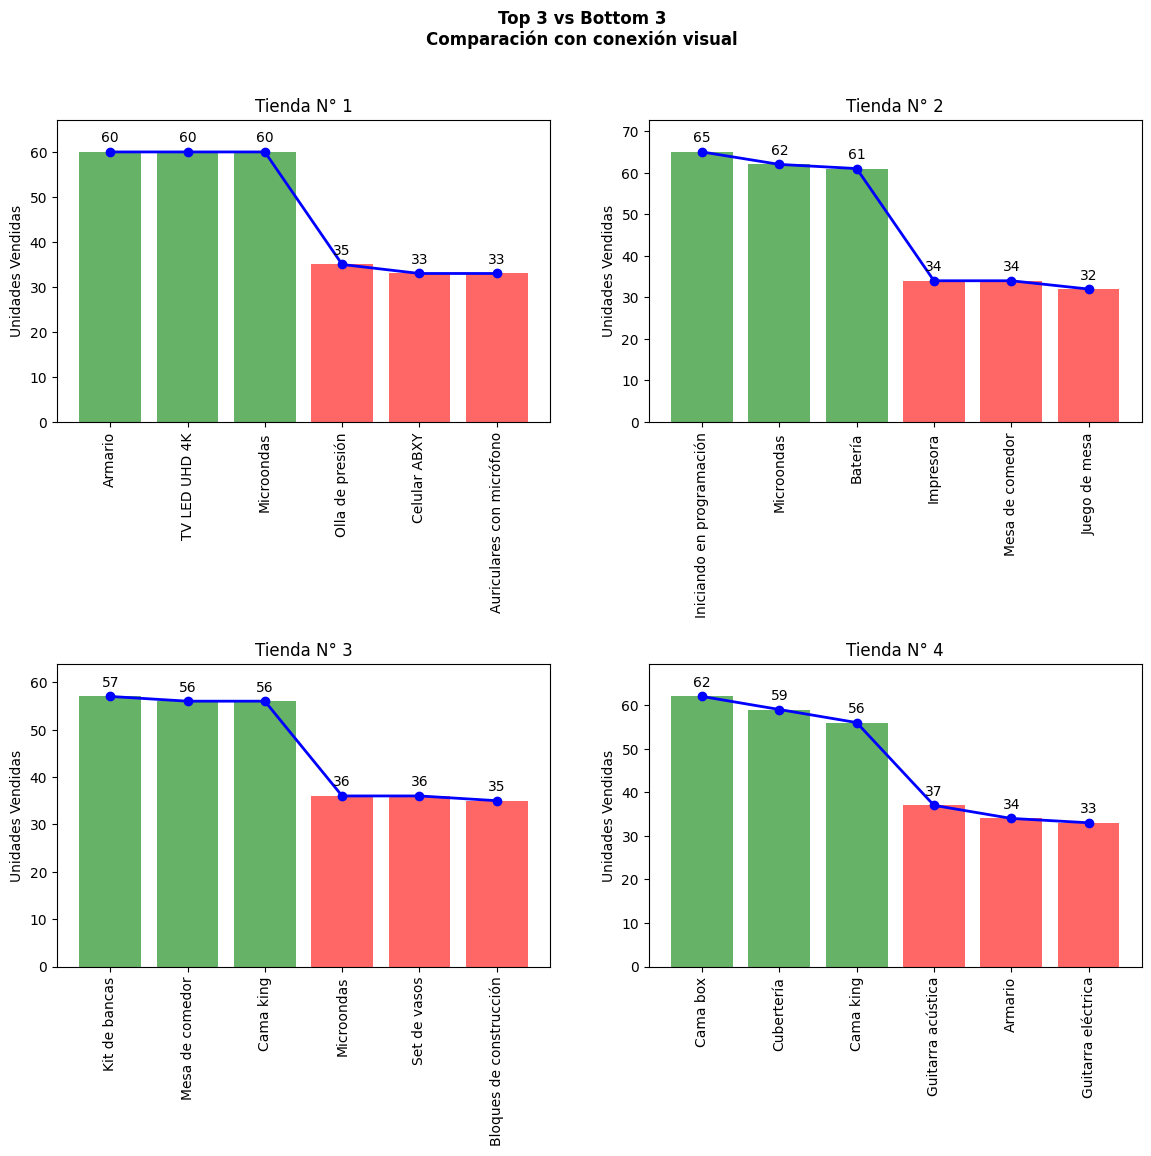

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))
colores = ["green"]*3 + ["red"]*3

#Generar Grafica
def Generar_grafica(fila,columna,df_grafica,nro_tienda):
  # Barras
  barra = axs[fila, columna].bar(
      df_grafica.index,
      df_grafica.values,
      color=colores,
      alpha=0.6
  )
  #Textos
  axs[fila, columna].set_title("Tienda N° "+str(nro_tienda))
  axs[fila, columna].set_ylabel("Unidades Vendidas")
  axs[fila, columna].tick_params(axis='x', rotation=90)
  axs[fila, columna].bar_label(barra, padding=5)
  axs[fila, columna].margins(y=0.12)

  # Línea encima
  axs[fila, columna].plot(
      df_grafica.index,
      df_grafica.values,
      color="blue",
      linewidth=2,
      marker='o'
  )
  return

# Arriba izquierda
Generar_grafica(0,0,top_bottom_tienda1,1)
# Arriba derecha
Generar_grafica(0,1,top_bottom_tienda2,2)
# Abajo izquierda
Generar_grafica(1,0,top_bottom_tienda3,3)
# Abajo derecha
Generar_grafica(1,1,top_bottom_tienda4,4)

plt.suptitle(
    "Top 3 vs Bottom 3\nComparación con conexión visual",
    fontsize=12,
    fontweight="bold"
)
plt.subplots_adjust(hspace=0.8)

plt.show()


# 5. Envío promedio por tienda

In [ ]:
df_tiendas["costo promedio de envio"] = [tienda["Costo de envío"].mean(),tienda2["Costo de envío"].mean(),tienda3["Costo de envío"].mean(),tienda4["Costo de envío"].mean()]
df_tiendas[["costo promedio de envio"]].style.format(
    {"costo promedio de envio": "${:.2f}"})

,costo promedio de envio
nombre,
tienda1,$26018.61
tienda2,$25216.24
tienda3,$24805.68
tienda4,$23459.46


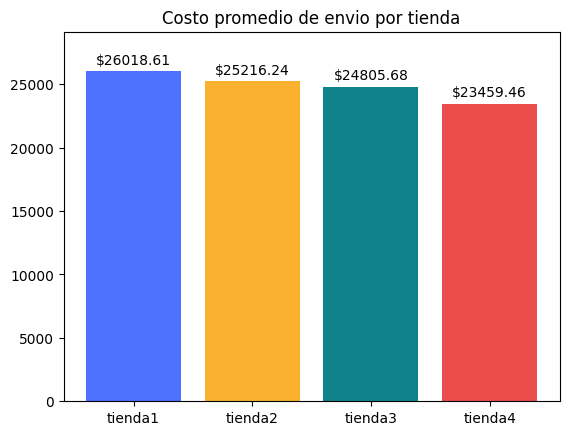

In [ ]:
barras = plt.bar(df_tiendas.index, df_tiendas["costo promedio de envio"], color=["#4E71FF", "#FAB12F", "#0F828C", "#EB4C4C"])
plt.title("Costo promedio de envio por tienda", fontsize=12)
plt.bar_label(barras,fmt="$%.2f", padding=3)
plt.margins(y=0.12)
plt.show()

# 6. Analisis Geografico

  ## 6.1 Concentracion de Ventas

In [ ]:
def calcular_metricas(df):
    return (
        df
        .assign(eficiencia_envio = 1 - df["Costo de envío"] / df["Precio"])
        .groupby(["lat","lon"])
        .agg(
            densidad_ventas=("lat","size"),
            eficiencia_promedio=("eficiencia_envio","median")
        )
    )

puntos_ventas_tienda1 = calcular_metricas(tienda)
puntos_ventas_tienda2 = calcular_metricas(tienda2)
puntos_ventas_tienda3 = calcular_metricas(tienda3)
puntos_ventas_tienda4 = calcular_metricas(tienda4)

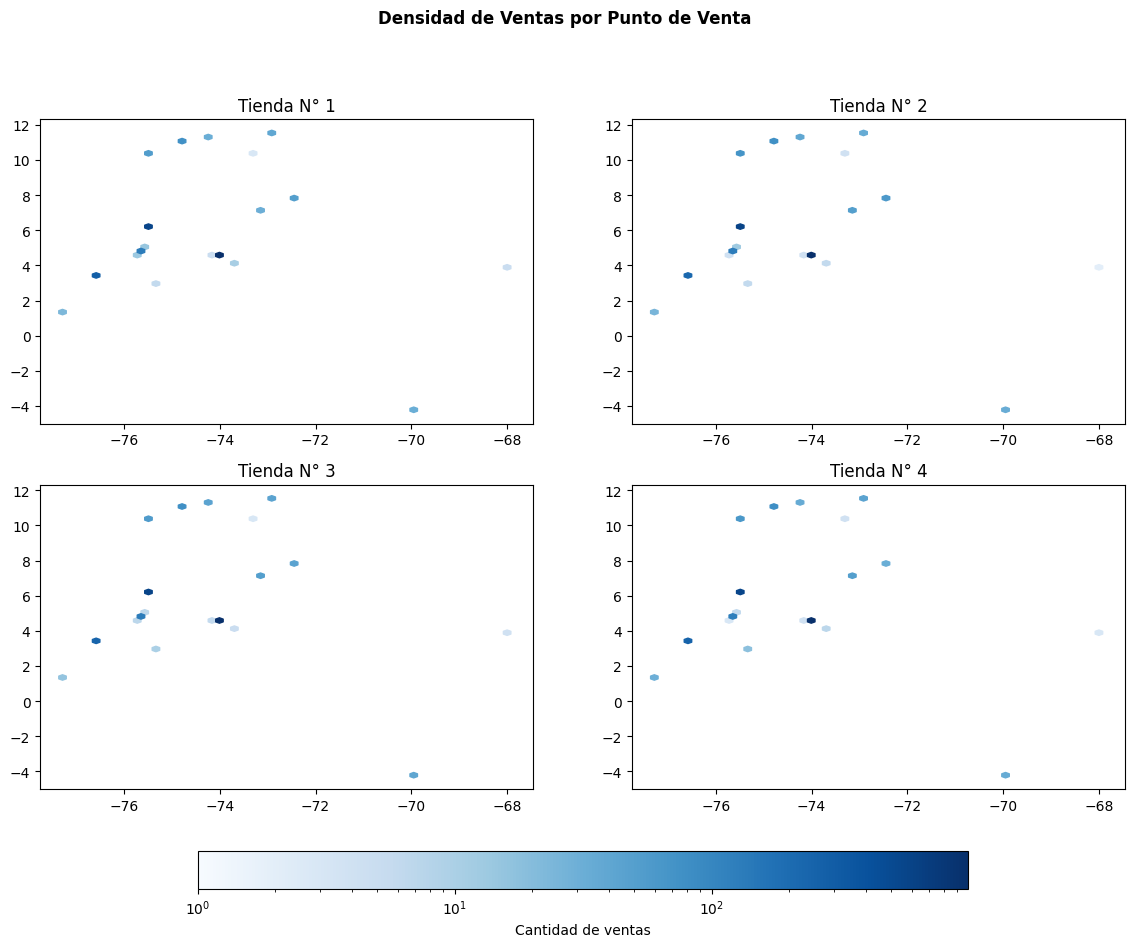

In [ ]:
import matplotlib.colors as colors

max_global = max(
    puntos_ventas_tienda1["densidad_ventas"].max(),
    puntos_ventas_tienda2["densidad_ventas"].max(),
    puntos_ventas_tienda3["densidad_ventas"].max(),
    puntos_ventas_tienda4["densidad_ventas"].max()
)

norm = colors.LogNorm(vmin=1, vmax=max_global)

fig, axs = plt.subplots(2, 2, figsize=(14, 11))
#Generar Grafica Heatmap
def Generar_grafica(fila,columna,df_grafica,nro_tienda):
  # Heatmap
  heatmap = axs[fila, columna].hexbin(
      df_grafica.index.get_level_values("lon"),
      df_grafica.index.get_level_values("lat"),
      C=df_grafica["densidad_ventas"],
      cmap = 'Blues',
      norm=norm,
      gridsize=60
  )

  #Textos
  axs[fila, columna].set_title("Tienda N° "+str(nro_tienda))

  return heatmap

# Arriba Izquierda
heatmap_pivote = Generar_grafica(0,0,puntos_ventas_tienda1,1)
# Arriba Derecha
Generar_grafica(0,1,puntos_ventas_tienda2,2)
#Abajo Izquierda
Generar_grafica(1,0,puntos_ventas_tienda3,3)
#Abajo Derecha
Generar_grafica(1,1,puntos_ventas_tienda4,4)

#Barra de calor
fig.subplots_adjust(bottom=0.18)
cbar = fig.colorbar(
    heatmap_pivote,
    ax=axs,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("Cantidad de ventas")


#Textos General
plt.suptitle(
    "Densidad de Ventas por Punto de Venta",
    fontsize=12,
    fontweight="bold"
)

plt.show()

  ## 6.2 Eficiencia de Envios

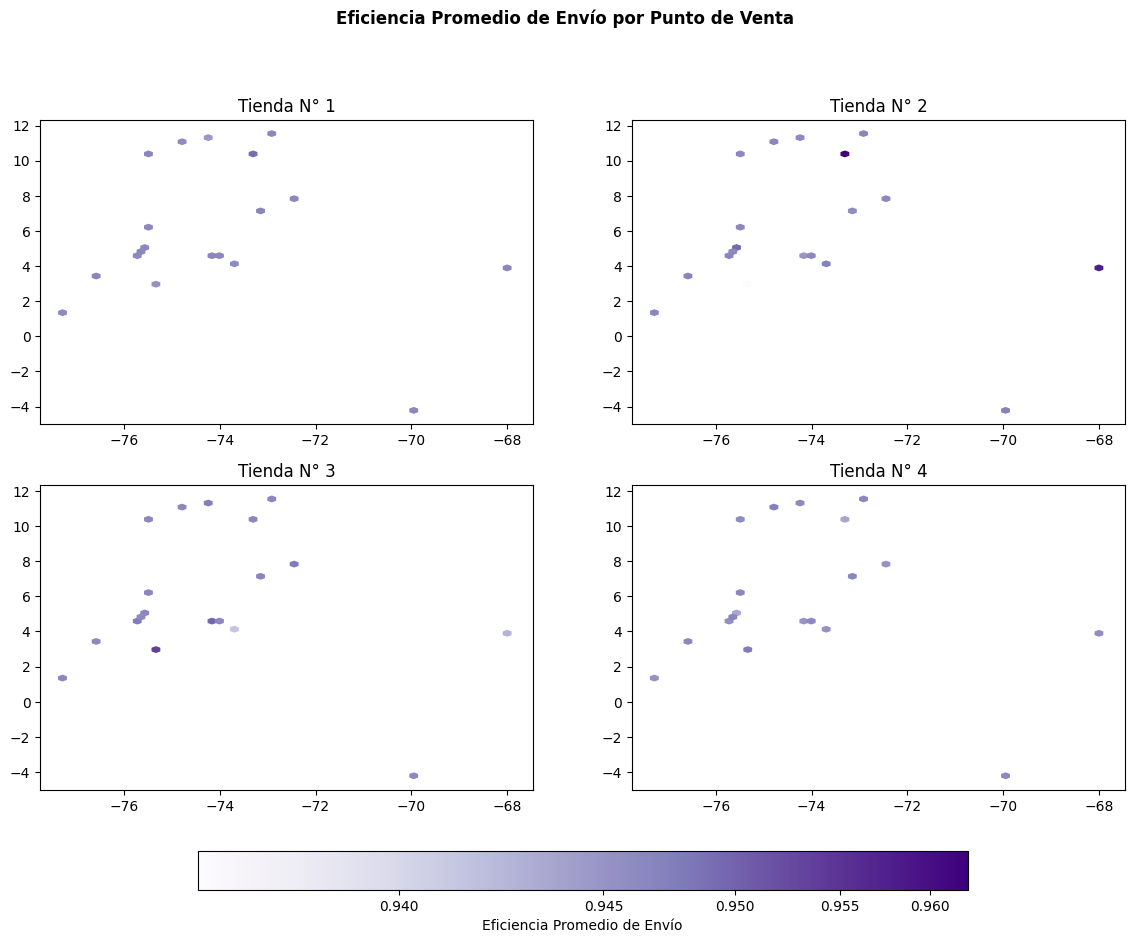

In [ ]:
# Normalización lineal entre min y max
min_ef = min(
    puntos_ventas_tienda1["eficiencia_promedio"].min(),
    puntos_ventas_tienda2["eficiencia_promedio"].min(),
    puntos_ventas_tienda3["eficiencia_promedio"].min(),
    puntos_ventas_tienda4["eficiencia_promedio"].min()
)

max_ef = max(
    puntos_ventas_tienda1["eficiencia_promedio"].max(),
    puntos_ventas_tienda2["eficiencia_promedio"].max(),
    puntos_ventas_tienda3["eficiencia_promedio"].max(),
    puntos_ventas_tienda4["eficiencia_promedio"].max()
)
norm_eficiencia = colors.PowerNorm(gamma=0.5, vmin=min_ef, vmax=max_ef)

fig, axs = plt.subplots(2, 2, figsize=(14, 11))

def Generar_grafica_eficiencia(fila, columna, df_grafica, nro_tienda):

    heatmap = axs[fila, columna].hexbin(
        df_grafica.index.get_level_values("lon"),
        df_grafica.index.get_level_values("lat"),
        C=df_grafica["eficiencia_promedio"],
        cmap='Purples',
        norm=norm_eficiencia,
        gridsize=60
    )

    axs[fila, columna].set_title("Tienda N° " + str(nro_tienda))

    return heatmap


# Generar gráficos
heatmap_pivote = Generar_grafica_eficiencia(0,0,puntos_ventas_tienda1,1)
Generar_grafica_eficiencia(0,1,puntos_ventas_tienda2,2)
Generar_grafica_eficiencia(1,0,puntos_ventas_tienda3,3)
Generar_grafica_eficiencia(1,1,puntos_ventas_tienda4,4)

# Espacio para barra
fig.subplots_adjust(bottom=0.18)

# Colorbar única
cbar = fig.colorbar(
    heatmap_pivote,
    ax=axs,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)

cbar.set_label("Eficiencia Promedio de Envío")

plt.suptitle(
    "Eficiencia Promedio de Envío por Punto de Venta",
    fontsize=12,
    fontweight="bold"
)

plt.show()

 ## 6.3 Mapa de Impacto Real

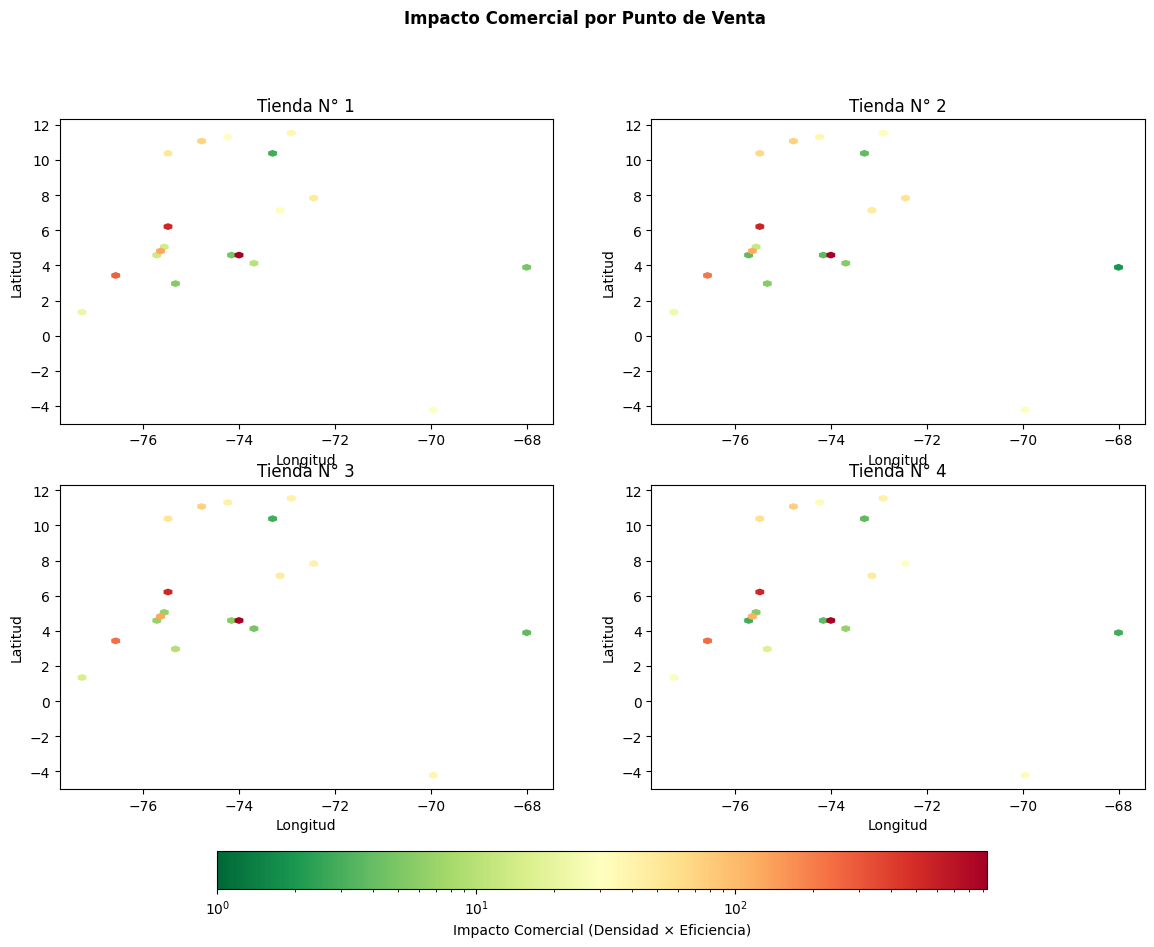

In [ ]:
import matplotlib.colors as colors

# =========================
# 1️⃣ Crear métrica impacto
# =========================

puntos_ventas_tienda1["impacto"] = (
    puntos_ventas_tienda1["densidad_ventas"] *
    puntos_ventas_tienda1["eficiencia_promedio"]
)

puntos_ventas_tienda2["impacto"] = (
    puntos_ventas_tienda2["densidad_ventas"] *
    puntos_ventas_tienda2["eficiencia_promedio"]
)

puntos_ventas_tienda3["impacto"] = (
    puntos_ventas_tienda3["densidad_ventas"] *
    puntos_ventas_tienda3["eficiencia_promedio"]
)

puntos_ventas_tienda4["impacto"] = (
    puntos_ventas_tienda4["densidad_ventas"] *
    puntos_ventas_tienda4["eficiencia_promedio"]
)

# =====================================
# 2️⃣ Normalización global (escala log)
# =====================================

max_impacto = max(
    puntos_ventas_tienda1["impacto"].max(),
    puntos_ventas_tienda2["impacto"].max(),
    puntos_ventas_tienda3["impacto"].max(),
    puntos_ventas_tienda4["impacto"].max()
)

norm_impacto = colors.LogNorm(vmin=1, vmax=max_impacto)

# ======================
# 3️⃣ Crear subplots
# ======================

fig, axs = plt.subplots(2, 2, figsize=(14, 11))

def Generar_grafica_impacto(fila, columna, df_grafica, nro_tienda):

    heatmap = axs[fila, columna].hexbin(
        df_grafica.index.get_level_values("lon"),
        df_grafica.index.get_level_values("lat"),
        C=df_grafica["impacto"],
        cmap="RdYlGn_r",
        norm=norm_impacto,
        gridsize=60
    )

    axs[fila, columna].set_title("Tienda N° " + str(nro_tienda))
    axs[fila, columna].set_xlabel("Longitud")
    axs[fila, columna].set_ylabel("Latitud")

    return heatmap


# ======================
# 4️⃣ Generar gráficos
# ======================

heatmap_pivote = Generar_grafica_impacto(0,0,puntos_ventas_tienda1,1)
Generar_grafica_impacto(0,1,puntos_ventas_tienda2,2)
Generar_grafica_impacto(1,0,puntos_ventas_tienda3,3)
Generar_grafica_impacto(1,1,puntos_ventas_tienda4,4)

# ======================
# 5️⃣ Colorbar global
# ======================

fig.subplots_adjust(bottom=0.18)

cbar = fig.colorbar(
    heatmap_pivote,
    ax=axs,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)

cbar.set_label("Impacto Comercial (Densidad × Eficiencia)")

# ======================
# 6️⃣ Título general
# ======================

plt.suptitle(
    "Impacto Comercial por Punto de Venta",
    fontsize=12,
    fontweight="bold"
)

plt.show()

# Conclusion del Analisis

Del análisis general se observa que la **Tienda 1** es la que mayor contribución realiza a las ganancias totales, representando el 26%, apenas por encima del resto de las tiendas (25%, 24% y 23%). En términos de volumen e impacto comercial, su desempeño es comparable al de las demás, y no presenta diferencias relevantes en la composición de productos más vendidos, menos vendidos ni en la distribución por categorías.

Sin embargo, al profundizar en los indicadores operativos aparecen señales claras de alerta. La **Tienda 1** tiene el mayor costo de envío promedio y, tanto en el análisis agregado como en el geográfico por punto de venta, muestra el peor rendimiento en eficiencia de envíos. Esta menor eficiencia coincide con su peor calificación de satisfacción al cliente, lo que sugiere una relación directa entre desempeño logístico y percepción del servicio.

En otras palabras, la tienda que más aporta en términos de ingresos es también la que presenta mayores debilidades operativas. Su liderazgo parece estar sostenido principalmente por volumen, no por eficiencia. Esto implica que, aunque actualmente su impacto global es similar al de las demás, su rentabilidad podría estar siendo presionada por costos logísticos elevados y por una experiencia de entrega menos favorable.

La conclusión es que el principal diferencial negativo de la **Tienda 1** no está en la oferta comercial, sino en la gestión de envíos. Optimizar este componente tendría un efecto relevante tanto en margen como en satisfacción del cliente, especialmente considerando el peso que esta tienda tiene dentro del resultado total.